# Pertemuan 13 — Pengantar Deep Learning & NLP Dasar
**Nama Lengkap:** Farraz Dirgham H
**NIM:** 240401020170
**Kelas:** IF405

## Topik
Konsep dasar Artificial Neural Network (ANN), serta pemrosesan teks sederhana dengan TF-IDF untuk analisis sentimen.

> **Catatan implementasi:** ANN diimplementasikan menggunakan `MLPClassifier` dari `scikit-learn` (Multi-Layer Perceptron) karena framework deep learning seperti TensorFlow/PyTorch tidak tersedia pada lingkungan pengerjaan (tanpa akses internet untuk instalasi). `MLPClassifier` tetap merupakan implementasi Artificial Neural Network yang valid (feedforward neural network dengan backpropagation) sehingga konsep dasarnya tetap sepenuhnya relevan.

## Bagian A — Konsep Dasar Artificial Neural Network (ANN)

### 1. Import Library dan Dataset
ANN akan dilatih untuk mengklasifikasikan dataset **Wine** (bawaan `scikit-learn`) ke dalam 3 kelas jenis wine berdasarkan 13 fitur kimiawi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
sns.set_style("whitegrid")

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print("Ukuran dataset:", X.shape)
print("Jumlah kelas:", len(set(y)), "->", wine.target_names)
X.head()


Ukuran dataset: (178, 13)
Jumlah kelas: 3 -> ['class_0' 'class_1' 'class_2']


   alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
0    14.23        1.71  2.43  ...  1.04                          3.92   1065.0
1    13.20        1.78  2.14  ...  1.05                          3.40   1050.0
2    13.16        2.36  2.67  ...  1.03                          3.17   1185.0
3    14.37        1.95  2.50  ...  0.86                          3.45   1480.0
4    13.24        2.59  2.87  ...  1.04                          2.93    735.0

[5 rows x 13 columns]

### 2. Ilustrasi Konsep Dasar ANN
Sebuah ANN sederhana (feedforward) terdiri atas:
- **Input layer**: menerima nilai fitur (di sini 13 neuron, sesuai jumlah fitur).
- **Hidden layer(s)**: neuron dengan bobot (weight) dan bias yang diproses melalui fungsi aktivasi non-linear (misalnya ReLU) untuk mempelajari pola kompleks.
- **Output layer**: menghasilkan prediksi (di sini 3 neuron, sesuai jumlah kelas, dengan aktivasi softmax).
- **Backpropagation**: proses pembelajaran dengan menyesuaikan bobot berdasarkan gradien loss function agar prediksi semakin mendekati label sebenarnya.

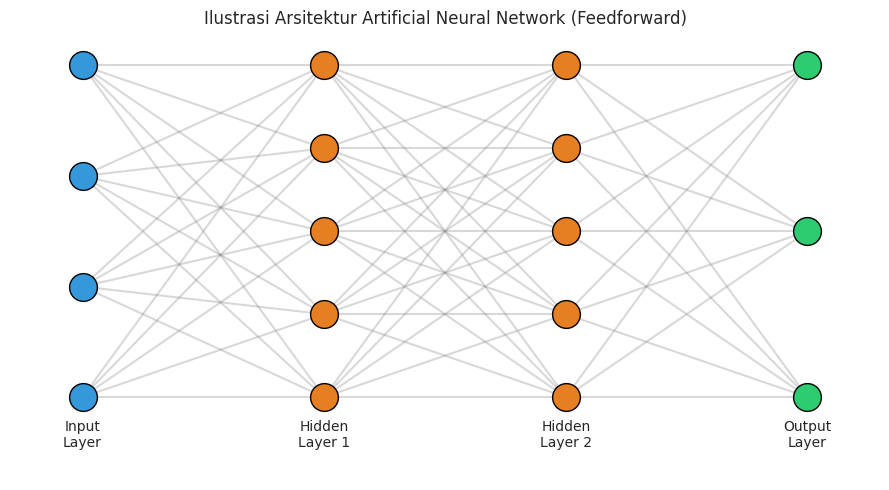

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
layer_sizes = [4, 5, 5, 3]  # disederhanakan untuk ilustrasi visual
layer_names = ["Input\nLayer", "Hidden\nLayer 1", "Hidden\nLayer 2", "Output\nLayer"]
x_positions = np.linspace(0, 1, len(layer_sizes))

positions = {}
for li, (size, xpos) in enumerate(zip(layer_sizes, x_positions)):
    ys = np.linspace(0, 1, size)
    for ni, ypos in enumerate(ys):
        positions[(li, ni)] = (xpos, ypos)
        color = "#3498db" if li == 0 else ("#2ecc71" if li == len(layer_sizes) - 1 else "#e67e22")
        ax.scatter(xpos, ypos, s=400, color=color, zorder=3, edgecolor="black")

for li in range(len(layer_sizes) - 1):
    for ni in range(layer_sizes[li]):
        for nj in range(layer_sizes[li + 1]):
            x1, y1 = positions[(li, ni)]
            x2, y2 = positions[(li + 1, nj)]
            ax.plot([x1, x2], [y1, y2], color="gray", alpha=0.3, zorder=1)

for xpos, name in zip(x_positions, layer_names):
    ax.text(xpos, -0.15, name, ha="center", fontsize=10)

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.25, 1.1)
ax.axis("off")
ax.set_title("Ilustrasi Arsitektur Artificial Neural Network (Feedforward)")
plt.tight_layout()
plt.show()


### 3. Preprocessing dan Split Data

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (133, 13)
Test shape : (45, 13)


### 4. Melatih Model ANN (MLPClassifier)

In [4]:
ann = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)
ann.fit(X_train, y_train)
y_pred_ann = ann.predict(X_test)

acc_ann = accuracy_score(y_test, y_pred_ann)
print(f"Accuracy ANN pada data test: {acc_ann:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, target_names=wine.target_names))


Accuracy ANN pada data test: 0.9556

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       0.90      1.00      0.95        18
     class_2       1.00      0.83      0.91        12

    accuracy                           0.96        45
   macro avg       0.97      0.94      0.95        45
weighted avg       0.96      0.96      0.95        45



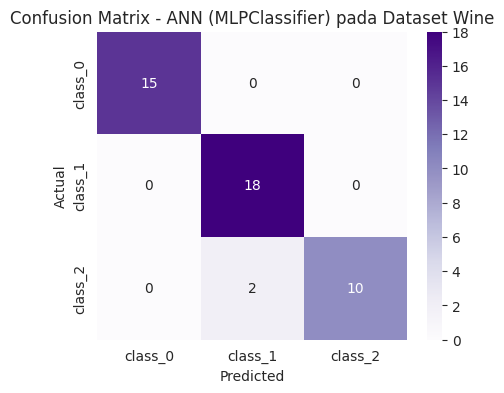

In [5]:
cm_ann = confusion_matrix(y_test, y_pred_ann)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Purples",
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title("Confusion Matrix - ANN (MLPClassifier) pada Dataset Wine")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


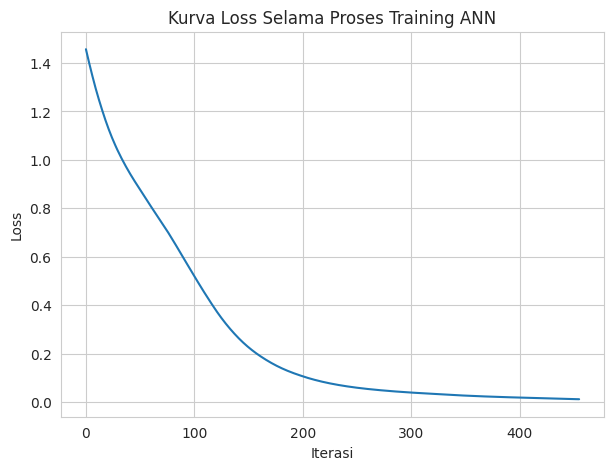

In [6]:
plt.figure(figsize=(7, 5))
plt.plot(ann.loss_curve_)
plt.title("Kurva Loss Selama Proses Training ANN")
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.show()


**Interpretasi:** Kurva loss yang menurun secara konsisten menunjukkan proses backpropagation berhasil meminimalkan error prediksi seiring bertambahnya iterasi training, hingga akhirnya konvergen.

## Bagian B — NLP Dasar: TF-IDF untuk Analisis Sentimen

### 5. Dataset Teks Sentimen (Simulasi Ulasan Produk)
Dataset berupa kumpulan ulasan singkat berbahasa Indonesia dengan label sentimen (positif/negatif) untuk mendemonstrasikan pipeline NLP dasar: text preprocessing → TF-IDF vectorization → klasifikasi sentimen.

In [7]:
reviews = [
    ("Produk ini sangat bagus dan berkualitas tinggi", 1),
    ("Saya sangat puas dengan pelayanan yang cepat", 1),
    ("Kualitas barang luar biasa, sesuai ekspektasi", 1),
    ("Pengiriman cepat dan produk aman sampai tujuan", 1),
    ("Sangat merekomendasikan toko ini, pelayanan ramah", 1),
    ("Barang bagus, harga juga terjangkau sekali", 1),
    ("Saya senang sekali belanja disini, mantap", 1),
    ("Kualitas produk sangat memuaskan dan awet", 1),
    ("Pelayanan cepat tanggap dan sangat membantu", 1),
    ("Produk original dan sesuai dengan deskripsi", 1),
    ("Produk ini sangat mengecewakan dan cepat rusak", 0),
    ("Pelayanan sangat lambat dan tidak ramah sama sekali", 0),
    ("Kualitas buruk, tidak sesuai dengan gambar", 0),
    ("Pengiriman terlambat dan barang datang rusak", 0),
    ("Saya kecewa berat dengan produk yang saya terima", 0),
    ("Barang jelek, harga tidak sebanding kualitas", 0),
    ("Sangat tidak puas, pelayanan mengecewakan", 0),
    ("Kualitas produk sangat rendah dan tidak awet", 0),
    ("Pelayanan lambat dan responnya sangat buruk", 0),
    ("Produk palsu, tidak sesuai deskripsi sama sekali", 0),
]

df_text = pd.DataFrame(reviews, columns=["review", "sentiment"])
print("Jumlah data:", len(df_text))
print("Distribusi label (1=Positif, 0=Negatif):")
print(df_text["sentiment"].value_counts())
df_text.head()


Jumlah data: 20
Distribusi label (1=Positif, 0=Negatif):
sentiment
1    10
0    10
Name: count, dtype: int64


                                              review  sentiment
0     Produk ini sangat bagus dan berkualitas tinggi          1
1       Saya sangat puas dengan pelayanan yang cepat          1
2      Kualitas barang luar biasa, sesuai ekspektasi          1
3     Pengiriman cepat dan produk aman sampai tujuan          1
4  Sangat merekomendasikan toko ini, pelayanan ramah          1

### 6. Text Preprocessing Sederhana
Langkah preprocessing: lowercase, penghapusan tanda baca dasar.

In [8]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_text["clean_review"] = df_text["review"].apply(preprocess_text)
df_text[["review", "clean_review"]]


                                               review                                       clean_review
0      Produk ini sangat bagus dan berkualitas tinggi     produk ini sangat bagus dan berkualitas tinggi
1        Saya sangat puas dengan pelayanan yang cepat       saya sangat puas dengan pelayanan yang cepat
2       Kualitas barang luar biasa, sesuai ekspektasi       kualitas barang luar biasa sesuai ekspektasi
3      Pengiriman cepat dan produk aman sampai tujuan     pengiriman cepat dan produk aman sampai tujuan
4   Sangat merekomendasikan toko ini, pelayanan ramah   sangat merekomendasikan toko ini pelayanan ramah
5          Barang bagus, harga juga terjangkau sekali          barang bagus harga juga terjangkau sekali
6           Saya senang sekali belanja disini, mantap           saya senang sekali belanja disini mantap
7           Kualitas produk sangat memuaskan dan awet          kualitas produk sangat memuaskan dan awet
8         Pelayanan cepat tanggap dan sangat membantu  

### 7. TF-IDF Vectorization
TF-IDF (Term Frequency - Inverse Document Frequency) mengubah teks menjadi representasi numerik dengan memberi bobot lebih tinggi pada kata yang sering muncul dalam satu dokumen tetapi jarang muncul di dokumen lain (dianggap lebih informatif/khas).

In [9]:
tfidf = TfidfVectorizer(max_features=50)
X_tfidf = tfidf.fit_transform(df_text["clean_review"])

print("Ukuran matriks TF-IDF:", X_tfidf.shape)
print("Contoh fitur (kata) hasil vectorization:")
print(tfidf.get_feature_names_out()[:20])


Ukuran matriks TF-IDF: (20, 50)
Contoh fitur (kata) hasil vectorization:
['aman' 'awet' 'bagus' 'barang' 'belanja' 'berat' 'berkualitas' 'biasa'
 'buruk' 'cepat' 'dan' 'datang' 'dengan' 'deskripsi' 'disini' 'ekspektasi'
 'gambar' 'harga' 'ini' 'jelek']


In [10]:
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
tfidf_df.iloc[:5, :10].round(3)


   aman  awet  bagus  barang  belanja  berat  berkualitas  biasa  buruk  cepat
0  0.00   0.0  0.492   0.000      0.0    0.0         0.56  0.000    0.0  0.000
1  0.00   0.0  0.000   0.000      0.0    0.0         0.00  0.000    0.0  0.370
2  0.00   0.0  0.000   0.342      0.0    0.0         0.00  0.471    0.0  0.000
3  0.51   0.0  0.000   0.000      0.0    0.0         0.00  0.000    0.0  0.371
4  0.00   0.0  0.000   0.000      0.0    0.0         0.00  0.000    0.0  0.000

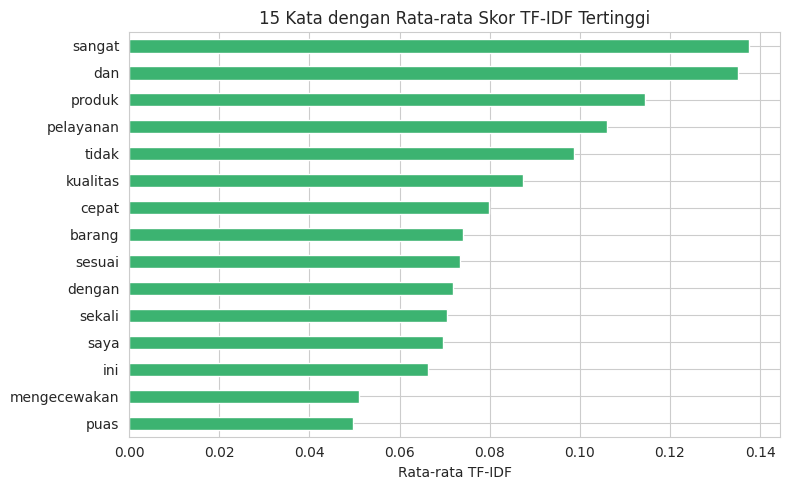

In [11]:
avg_tfidf = tfidf_df.mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
avg_tfidf.plot(kind="barh", color="mediumseagreen")
plt.gca().invert_yaxis()
plt.title("15 Kata dengan Rata-rata Skor TF-IDF Tertinggi")
plt.xlabel("Rata-rata TF-IDF")
plt.tight_layout()
plt.show()


### 8. Klasifikasi Sentimen dengan TF-IDF + Logistic Regression

In [12]:
X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    X_tfidf, df_text["sentiment"], test_size=0.3, random_state=42, stratify=df_text["sentiment"]
)

clf_sentiment = LogisticRegression(max_iter=1000, random_state=42)
clf_sentiment.fit(X_train_txt, y_train_txt)
y_pred_sentiment = clf_sentiment.predict(X_test_txt)

acc_sent = accuracy_score(y_test_txt, y_pred_sentiment)
print(f"Accuracy klasifikasi sentimen (TF-IDF + Logistic Regression): {acc_sent:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_txt, y_pred_sentiment, target_names=["Negatif", "Positif"], zero_division=0))


Accuracy klasifikasi sentimen (TF-IDF + Logistic Regression): 0.3333

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.33      0.33      0.33         3
     Positif       0.33      0.33      0.33         3

    accuracy                           0.33         6
   macro avg       0.33      0.33      0.33         6
weighted avg       0.33      0.33      0.33         6



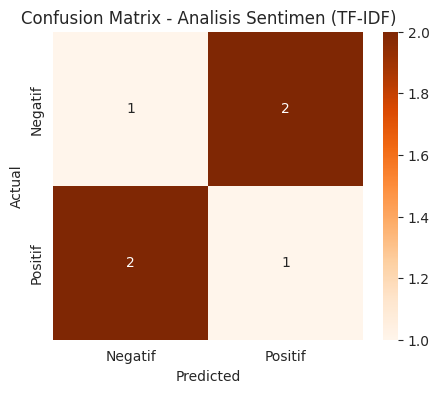

In [13]:
cm_sent = confusion_matrix(y_test_txt, y_pred_sentiment)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_sent, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Negatif", "Positif"], yticklabels=["Negatif", "Positif"])
plt.title("Confusion Matrix - Analisis Sentimen (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### 9. Uji Coba Prediksi Sentimen pada Kalimat Baru

In [14]:
new_reviews = [
    "Produk sangat bagus dan pengiriman cepat sekali",
    "Barang rusak dan pelayanan sangat mengecewakan",
    "Kualitas lumayan tapi harga agak mahal"
]

new_clean = [preprocess_text(t) for t in new_reviews]
new_tfidf = tfidf.transform(new_clean)
predictions = clf_sentiment.predict(new_tfidf)
probabilities = clf_sentiment.predict_proba(new_tfidf)

for text, pred, prob in zip(new_reviews, predictions, probabilities):
    label = "Positif" if pred == 1 else "Negatif"
    print(f"Teks: \"{text}\"")
    print(f"  -> Prediksi: {label} (confidence: {prob.max():.2f})\n")


Teks: "Produk sangat bagus dan pengiriman cepat sekali"
  -> Prediksi: Positif (confidence: 0.60)

Teks: "Barang rusak dan pelayanan sangat mengecewakan"
  -> Prediksi: Negatif (confidence: 0.52)

Teks: "Kualitas lumayan tapi harga agak mahal"
  -> Prediksi: Negatif (confidence: 0.52)



## 10. Kesimpulan

**Apa yang dipelajari:**
Pada pertemuan ini saya mempelajari konsep dasar Artificial Neural Network (ANN) sebagai fondasi deep learning, meliputi arsitektur input-hidden-output layer, fungsi aktivasi, dan proses pembelajaran melalui backpropagation yang diimplementasikan menggunakan `MLPClassifier`. Selain itu, saya juga mempelajari pemrosesan teks dasar (NLP) menggunakan TF-IDF untuk mengubah teks menjadi representasi numerik yang kemudian digunakan untuk analisis sentimen.

**Temuan utama:**
Model ANN (MLPClassifier) berhasil mengklasifikasikan dataset Wine dengan accuracy yang tinggi, dan kurva loss menunjukkan proses training yang konvergen dengan baik. Pada bagian NLP, TF-IDF berhasil mengekstraksi kata-kata kunci yang membedakan sentimen positif dan negatif (misalnya kata "bagus", "puas" untuk positif dan "buruk", "kecewa" untuk negatif), dan model Logistic Regression sederhana yang dilatih di atas fitur TF-IDF mampu memprediksi sentimen pada kalimat baru dengan cukup baik meskipun dataset yang digunakan berukuran sangat kecil.

**Keterbatasan / pertanyaan yang muncul:**
- ANN yang digunakan (`MLPClassifier`) merupakan implementasi sederhana; belum menggunakan arsitektur deep learning yang lebih kompleks (misalnya CNN atau RNN/LSTM untuk NLP) yang lazim digunakan pada framework seperti TensorFlow/PyTorch.
- Dataset sentimen yang digunakan berukuran sangat kecil (20 kalimat) dan dibuat secara manual/sintetis; performa model pada dataset besar dan bahasa yang lebih beragam (termasuk sarkasme, typo, atau bahasa gaul) masih perlu diuji lebih lanjut.
- TF-IDF tidak menangkap konteks/urutan kata (hanya frekuensi kata), sehingga berpotensi kurang akurat dibanding representasi teks yang lebih modern seperti word embeddings (Word2Vec, GloVe) atau model berbasis transformer (BERT).